# 语义的飞跃：词嵌入技术与稠密表示

通过本次任务，你将学会使用词嵌入（Word Embedding）技术提高情感分析模型的能力。

## 任务背景

夜深人静，面对奶茶店后台系统中不断滚动的用户评价，你再次感到棘手。尽管之前引入循环神经网络显著降低了模型的参数量，缓解了对高显存昂贵显卡的依赖，但模型的分类效果却大幅下降——它难以准确捕捉用户评价中细腻的情感倾向。

问题的根源在于词语的 One‑Hot 表示方式。这种编码让每个词都成了孤岛：“醇香”与“浓郁”、“美味”与“好喝”……在模型看来，它们之间毫无关联。

你揉揉眉心，目光扫过屏幕上流动的文字。一条评价闪过：“芋泥香气扑鼻，和牛奶搭配简直天作之合。”

忽然间，一个念头像星火般闪过：**近朱者赤，近墨者黑。一个词的意义，不正是由它周围的词所定义的吗？**

词义并非孤立存在，一个词的涵义可以由它周围那些词共同描绘。如果用周围词的分布来表示当前词，结果会怎样呢？也许“醇厚”会自然靠近“浓郁”，“失望”会隐约指向“不满”，而所有关于“甜度”的讨论，都将在某个维度悄然汇聚。

这仿佛为你的 AI 模型开启了一扇新的感知之门，使它得以越过符号的表层，触及语言之下流动的语义与情感。

探索仍在继续。这一次，我们要教会模型真正学会“阅读”。

## 最少必要知识

- 词嵌入（Word Embedding）

## 任务鸟瞰

### 任务分析


本次的任务是使用更好的稠密词嵌入代替 OneHot 独热编码，提高情感分析模型的性能。

![任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154543.png)


在具体展开之前，我们不妨先通过一个简单的例子来直观感受 OneHot 编码的局限性。假设我们有一个小型词汇表：`{猪、猫、狗、鸟、鱼、鸡}`。
如果使用 OneHot 编码，每个词会被表示为一个仅有一个位置为 1、其余全为 0 的向量。例如：
- “猪” → `[1, 0, 0, 0, 0, 0]`
- “猫” → `[0, 1, 0, 0, 0, 0]`
- “狗” → `[0, 0, 1, 0, 0, 0]`
- ......

![OneHot示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154657.png)

这种表示虽然简单直观，却存在几个明显的问题：
1. **维度稀疏**：向量长度等于词汇表大小，大部分位置为零，存储和计算效率低。
2. **相互正交**：任意两个词的向量点积为零，无法反映它们之间的任何关联。
3. **语义鸿沟**：无法表达“猫和狗都是宠物”、“鸟和鸡都有翅膀”等语义或常识关系。


如果我们尝试从现实特征的角度重新表示这些动物，例如使用“脚的数量”和“平均体重（kg）”这两个维度，可能会得到如下表示：
- “猪” → `[4, 100]`
- “猫” → `[4, 4]`
- “狗” → `[4, 15]`
- “鸟” → `[2, 0.5]`
- “鱼” → `[0, 1]`
- “鸡” → `[2, 2]`

![词嵌入示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154717.png)

尽管这组特征非常简化，但已经可以看出：**仅用二维向量，我们就能够捕捉到动物之间的某些物理相似性**。例如，“猫”和“狗”在脚的数量上相同，体重也相对接近；“鸟”和“鸡”在脚的数量上一致。相比 OneHot 编码，这种低维、稠密的表示在保留关键信息的同时，大幅压缩了维度。

这正是**词嵌入**（Word Embedding）的基本思想：通过一个低维、连续、稠密的向量空间来表示词汇，使得语义或语法相似的词在空间中距离更近。**简单来说，你可以把词嵌入想象成给每个词绘制一张“语义地图”。**在这张地图上，语义相近的词（如“猫”和“狗”）会住得很近，而意思不同的词（如“银行”和“香蕉”）则相距甚远。


:::{admonition} 词嵌入的神奇
:class: note

词嵌入的神奇之处在于，通过简单的向量运算就能完成复杂的语义推理，下面是几个非常典型的例子：

- 👑 国王 - 男人 + 女人 = 女王
向量运算“国王 - 男人 + 女人”的结果向量，在语义空间中最接近“女王”的向量。
- 🏙️ 巴黎 - 法国 + 日本 = 东京
首都关系：巴黎之于法国，如同东京之于日本。这种类比关系被编码在向量的相对位置中。
- 📚 作家 - 小说 + 诗歌 = 诗人
职业与作品类型的关系也被学习到了向量表示中。
:::


在 NLP 任务中，通常使用词嵌入层根据下游任务自动学习词的分布式表示，通常维度在 50～300 之间，每一维并不对应具体的人类可解释特征，但整体能够捕捉丰富的语义。接下来，我们将使用词嵌入层进一步优化情感分析模型。


### 模型结构

下面我们使用词嵌入层来优化情感分析模型。模型结构如下：

![模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154602.png)

模型结构中，使用了 Embedding 层代替了 OneHot 编码，从而使得模型能够学习到词的分布式表示。

独热编码的数据处理示例如下：

![OneHot 数据处理](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260205092021.png)

词嵌入的数据处理示例如下：

![数据处理流程](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154626.png)

词嵌入的 Token 向量是稠密的，相对稀疏的 OneHot 编码维度更少，语义表示更加丰富。

![稠密嵌入和稀疏嵌入的对比](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210154752.png)

下面我们进入实战部分，依然沿用 NLP 任务的通用开发流程组织本章内容：定义分词器、数据准备、模型定义、模型训练与模型评估。本次的改动较少，重复代码不再进行赘述。

在正式开始之前，先配置环境，避免因为环境不同而导致程序不能复现。

## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm

### 环境版本

In [2]:
from dsxllm.util import show_version

show_version()

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 自定义分词器

此部分代码和前面章节一致。

In [3]:
class SimpleTokenizer:
    def __init__(self, pad_at_beginning=False):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'
        self.pad_at_beginning = pad_at_beginning

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length, pad_at_beginning=False):
        """
        对序列进行填充或截断
        
        Args:
            sequences: 序列列表
            max_length: 最大长度
            pad_at_beginning: 是否在序列开头填充，默认为False（在末尾填充）
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                if pad_at_beginning:
                    # 从开头截断
                    padded_seq = seq[len(seq) - max_length:]
                else:
                    # 从末尾截断
                    padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padding = [self.pad_token_id] * pad_length
                if pad_at_beginning:
                    # 在开头填充
                    padded_seq = padding + seq
                else:
                    # 在末尾填充
                    padded_seq = seq + padding

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length, self.pad_at_beginning)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

## 准备数据


### 数据集下载

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 自定义数据转化器

只使用 SimpleTokenizer 进行分词，将文本编码成 token ids 序列。

In [4]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=20, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        return input_ids

### 自定义文本分类数据集

创建自定义文本分类数据集类，继承 torch.utils.data.Dataset 类。

In [5]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)

        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

### 自定义文本分类数据模组

In [6]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 训练、验证和测试数据文件路径
        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径（可选）
        self.test_data_file = test_data_file  # 测试数据文件路径（可选）

        # 数据集实例，初始为None，在setup方法中初始化
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

        # 批次大小和数据转换器
        self.batch_size = batch_size  # 每个批次的样本数量
        self.transform = transform  # 数据转换器，用于预处理数据

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        # 此方法通常用于下载数据或进行一次性操作
        pass

    def setup(self, stage=None):
        # 根据阶段加载数据集
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file, transform=self.transform)

        # 如果未提供验证数据文件，则使用训练数据集作为验证集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            # 否则加载指定的验证数据集
            self.val_dataset = TextClassificationDataset.from_file(self.val_data_file, transform=self.transform)

        # 如果未提供测试数据文件，则使用验证数据集作为测试集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            # 否则加载指定的测试数据集
            self.test_dataset = TextClassificationDataset.from_file(self.test_data_file, transform=self.transform)

    def train_dataloader(self):
        # 返回训练数据的DataLoader，启用shuffle以打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## 改进情感分析模型

### 自定义 RNN 计算单元

RNNCell的计算图：

![RNNCell的计算图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210083338.png)

RNN 计算单元的计算过程为：$h_t = tanh(W_{xh} * x_t + W_{hh} * h_{t-1} + b_h)$。

RNN 计算单元的实现代码如下：

In [7]:
import torch
from torch import nn


class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        初始化RNNCell。

        参数:
        - input_size: 输入的特征维度大小
        - hidden_size: 隐藏状态的维度大小
        """

        super(RNNCell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # 输入到隐藏特征的权重：W_x
        self.weight_xh = nn.Parameter(torch.randn(input_size, hidden_size))

        # 隐藏特征到隐藏特征的权重：W_h
        self.weight_hh = nn.Parameter(torch.randn(hidden_size, hidden_size))

        # 偏置项： b
        self.bias = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, input, hidden_prev):
        """
        前向传播。

        参数:
        - input: 当前时刻的输入 (batch_size, input_size)
        - hidden_prev: 上一时刻的隐藏状态 (batch_size, hidden_size)

        返回:
        - hidden_current: 当前时刻的隐藏状态 (batch_size, hidden_size)
        """
        # 当前时刻的隐藏状态 = 激活函数（前一个时刻的隐藏状态 + 当前输入的信息）
        hidden_current = torch.tanh(
            torch.matmul(hidden_prev, self.weight_hh) +
            torch.matmul(input, self.weight_xh) +
            self.bias
        )

        return hidden_current

### 自定义 RNN 层

同样的，我们也来回顾一下 RNN 层的展开视图：

![RNNCell的示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093124.png)

具体的实现代码如下：

In [8]:
from torch import nn


class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        初始化RNN层。

        参数:
        - input_size: 输入的特征维度大小
        - hidden_size: 隐藏状态的维度大小
        """
        super(RNN, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        self.rnn_cell = RNNCell(input_size, hidden_size)

    def forward(self, inputs, hidden=None):
        """
        前向计算

        参数:
        - inputs: 输入序列 (batch_size, seq_len, input_size)
        - hidden: 初始隐藏状态 (batch_size, hidden_size)，默认为零初始化

        返回:
        - outputs: 所有时间步的隐藏状态 (batch_size, seq_len, hidden_size)
        """
        batch_size, seq_len, _ = inputs.size()

        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size).type_as(inputs)

        outputs = []

        for t in range(seq_len):
            hidden = self.rnn_cell(inputs[:, t, :], hidden)  # 按时间步处理
            outputs.append(hidden)

        outputs = torch.stack(outputs, dim=1)  # 沿着seq_len维度堆叠 (batch_size, seq_len, hidden_size)
        return outputs

### 情感分析模型的代码重构

这是本章改进的重点，使用词嵌入（Word Embedding）重构情感分类模型。在 RNN 层之前添加一个词嵌入层 `embedding_layer`，将 Token ID 转换为向量表示。所以，它的 `num_embeddings` 为词表大小（`vocab_size`），`embedding_dim` 为嵌入维度大小（`hidden_size`）。

In [9]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, vocab_size=10, hidden_size=128, num_classes=2, learning_rate=0.01):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        # 🌟改进点：使用词嵌入层自动学习 Token 的向量表示，而不再使用 one-hot
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)  # 词嵌入层
        self.rnn = RNN(input_size=hidden_size, hidden_size=hidden_size)  # RNN层
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(in_features=hidden_size, out_features=num_classes)  # 输出层

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.randint(0, vocab_size, (32, 30), dtype=torch.long)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, input_ids):
        """前向传播"""

        input_emb = self.embedding_layer(input_ids)  # 数据形状：(batch_size, seq_len) → (batch_size, seq_len, hidden_size)

        # 通过RNN层处理输入序列
        outputs = self.rnn(input_emb)  # 数据形状: (batch_size, seq_len, hidden_size) → (batch_size, seq_len, hidden_size)

        # 取最后一个时间步的输出作为特征
        last_output = outputs[:, -1, :]  # 形状: (batch_size, hidden_size)

        last_output = self.relu(last_output)

        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_output)  # 数据形状: (batch_size, hidden_size) → (batch_size, num_classes)

        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

### 情感分析模型的详细信息

初始化模型并查看详细的摘要信息。

In [10]:
# 导入模型摘要工具，用于查看模型的结构和参数信息
from lightning.pytorch.utilities.model_summary import ModelSummary

# 指定训练数据文件路径
file_path = "./dataset/comments_train.txt"

# 初始化分词器并从训练数据文件中构建词汇表
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file(file_path)

# 初始化情感分类模型，设置模型的词表大小等于分词器的词汇表大小，隐藏层大小为128，分类数为2（正面/负面），学习率为0.001
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 生成模型摘要，max_depth=-1表示显示所有层级的详细信息
summary = ModelSummary(model, max_depth=-1)

# 打印模型摘要信息
print(summary)

  | Name            | Type      | Params | Mode  | FLOPs  | In sizes               | Out sizes    
--------------------------------------------------------------------------------------------------------
0 | embedding_layer | Embedding | 220 K  | train | 0      | [32, 30]               | [32, 30, 128]
1 | rnn             | RNN       | 32.9 K | train | 62.9 M | [32, 30, 128]          | [32, 30, 128]
2 | rnn.rnn_cell    | RNNCell   | 32.9 K | train | 62.9 M | [[32, 128], [32, 128]] | [32, 128]    
3 | relu            | ReLU      | 0      | train | 0      | [32, 128]              | [32, 128]    
4 | output_layer    | Linear    | 258    | train | 16.4 K | [32, 128]              | [32, 2]      
--------------------------------------------------------------------------------------------------------
253 K     Trainable params
0         Non-trainable params
253 K     Total params
1.016     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
62.

从模型摘要信息可以看出，当前的情感分析模型主要由三个核心层构成：
- **embedding_layer（词嵌入层）**：责将输入的文本序列映射为稠密的词向量表示，捕捉词汇语义信息；
- **rnn（循环神经网络层）**：对序列信息进行建模，能够结合上下文捕捉整个文本中的语义信息；
- **output_layer（输出层）**：根据整个文本的语义信息生成对应情感类别的预测分数；

整个模型通过这三层的逐级处理，完成从原始文本到情感分类结果的端到端学习。

## 模型训练与评估

### 初始化模型和训练器

In [11]:
# 超参配置
max_length = 30
batch_size = 32

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(pad_at_beginning=True)
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 2️⃣ 创建 TextTransform 实例
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 创建 DataModule 实例
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file="./dataset/comments_train.txt")

# 4️⃣ 创建 TextClassifier 模型实例
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 5️⃣ 创建PyTorch Lightning训练器，设置训练参数：
# - max_epochs=12: 最大训练轮数为12
# - log_every_n_steps=3: 每3个步骤记录一次日志
# - check_val_every_n_epoch=3: 每3个epoch进行一次验证
# - enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练前评估

训练前评估为模型性能建立初始基准。

In [12]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1383.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.5069648027420044     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1383.0,
  'val_overall_acc': 0.5069648027420044}]

未经训练时，模型的预测准确率为 `50.69%`，该数值与随机猜测水平相近，表明模型在初始状态下并不具备有效的预测能力。

### 训练模型

In [13]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃   ┃ Name            ┃ Type      ┃ Params ┃ Mode  ┃  FLOPs ┃      In sizes ┃     Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0 │ embedding_layer │ Embedding │  220 K │ train │      0 │      [32, 30] │ [32, 30, 128] │
│ 1 │ rnn             │ RNN       │ 32.9 K │ train │ 62.9 M │ [32, 30, 128] │ [32, 30, 128] │
│ 2 │ relu            │ ReLU      │      0 │ train │      0 │     [32, 128] │     [32, 128] │
│ 3 │ output_layer    │ Linear    │    258 │ train │ 16.4 K │     [32, 128] │       [32, 2] │
└───┴─────────────────┴───────────┴────────┴───────┴────────┴───────────────┴───────────────┘

Trainable params: 253 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 253 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 62.9 M

`Trainer.fit` stopped: `max_epochs=12` reached.


调用 `trainer.fit()` 训练 12 个轮次。

#### 训练过程可视化

绘制训练过程中损失值的曲线，更直观地观察模型性能变化的趋势。

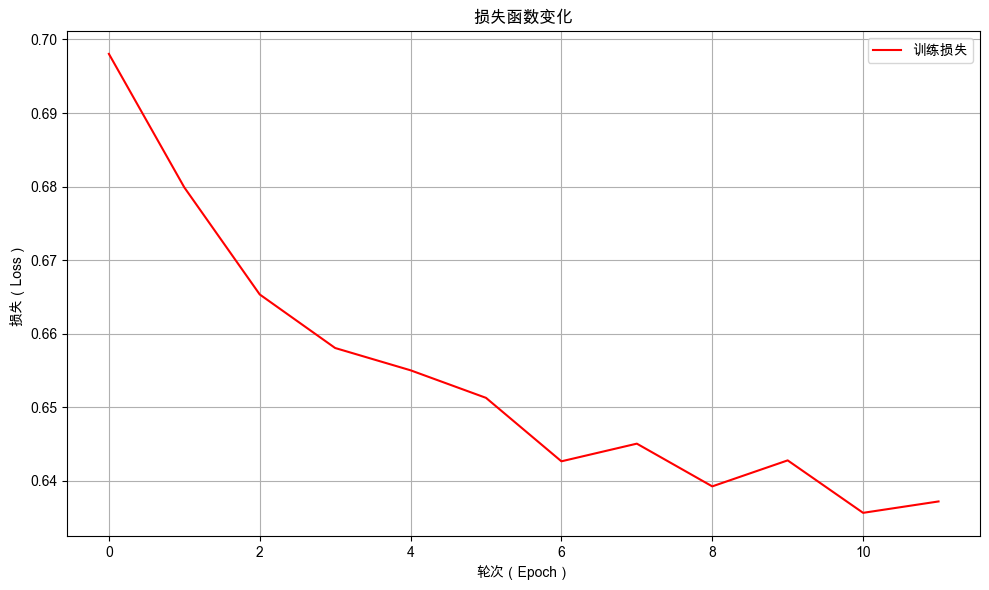

In [14]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)


从图中可以看出随着训练的进行，损失值不断下降，表示模型预测准确性不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [15]:
from dsxllm.util import to_dataframe

to_dataframe(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,2728,1534,0.5623
1,1,2728,1615,0.5920
2,2,2728,1623,0.5949
3,3,2728,1637,0.6001
4,4,2728,1678,0.6151
5,5,2728,1701,0.6235
6,6,2728,1716,0.6290
7,7,2728,1713,0.6279
8,8,2728,1739,0.6375
9,9,2728,1725,0.6323


### 训练后评估

In [16]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1736.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.6363636255264282     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1736.0,
  'val_overall_acc': 0.6363636255264282}]

模型经过训练后，预测准确率从训练前的 `50.69%` 提升至 `63.63%`。相比之前有显著提升，这说明词嵌入确实是一种比 OneHot 编码更有效的文本表示方法，但模型性能仍需进一步优化。

## 使用模型进行预测

针对一组包含不同长度（短、中、长）且情感倾向明确的顾客评论进行推理预测，直观观察模型的预测效果。

In [17]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from dsxllm.util import print_classification_predictions

# 1. 准备需要预测的文本（长短不一）
new_texts = [
    # 短文本
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]

# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)

# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_predictions(new_texts, true_labels, predictions, probabilities, model.label_map)

🎯 分类预测结果 (准确率: 5/10 = 50.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  0.5566  |  ☑   |
|                      质量差                      |   负面   |   负面   |  0.6752  |  ☑   |
|                     推荐购买                     |   正面   |   负面   |  0.6316  |  ☒   |
|                     不建议买                     |   负面   |   负面   |  0.6613  |  ☑   |
|                  这个产品还不错                  |   正面   |   正面   |  0.6472  |  ☑   |
|                  物流速度太慢了                  |   负面   |   负面   |  0.8119  |  ☑   |
|                性价比很高值得推荐                |   正面   |   负面   |  0.6569  |  ☒   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   负面   |  0.6456  |  ☒   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   正面   |  0.5492 

本次预测也只有 `50%` 的正确率，还是很差，需要进一步优化模型。

## 泛化能力评估

In [18]:
from dsxllm.util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="./dataset/comments_train.txt",
                             val_data_file="./dataset/comments_val.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1736.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.6363636255264282     │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1691.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │    0.6063104867935181     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 1691.0,
  'val_overall_acc': 0.6063104867935181}]

使用词嵌入的模型在训练集上的准确率为 `63.63%`，在评估集上的准确率为 `60.63%`，指标下降不明显，未发生明显过拟合。

## 问题分析

虽然本次的模型在评估集上的准确率为 `60.63%`，但模型性能仍未达到预期目标，需进一步优化。为什么会这样呢？

因为 RNN 虽然可以记忆过去的信息，但许多情况下它都无法很好地学习到时序数据的长期依赖关系，实际效果并不好。原因在于**RNN计算单元会发生梯度消失和梯度爆炸的问题**。
- 如果发生梯度爆炸，最终就会导致溢出，出现 NaN（Not a Number，非数值）之类的值，导致神经网络无法正常训练。
- 如果发生梯度消失，梯度将迅速变小。一旦梯度变小，权重梯度不能被更新，模型就会无法学习长期的依赖关系。


为什么基础 RNN 会遇到梯度消失和梯度爆炸问题呢？

基于 RNN 的反向传播与梯度流动如下图所示：

![RNN梯度反向传播](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211092320.png)

**梯度消失和梯度爆炸的原因：RNN 反向传播的梯度流经 tanh、“+”和 MatMul（矩阵乘积）运算。**
- **加法运算**：反向传播时，梯度直接传递至下游，其数值保持不变。
- **tanh 激活函数**：tanh 的梯度绝对值小于 1。因此，每经过一次 tanh 节点，梯度值就会相应衰减。若序列长度为 T，梯度将经历 T 次衰减，从而可能导致梯度消失。若改用 ReLU 等激活函数，可在一定程度上缓解该问题。
- **矩阵乘法（MatMul）**：梯度在通过 MatMul 节点时，其幅度会随时间步长呈指数级变化。若权重矩阵的最大奇异值大于 1，梯度可能指数级增大（爆炸）；若最大奇异值小于 1，梯度则可能指数级减小（消失）。矩阵的奇异值反映了数据在该变换方向上的伸缩程度。

在下一章节中，我们将使用**门控循环单元**（Gated Recurrent Unit, GRU）替代基础循环神经网络（RNN），解决梯度消失和梯度爆炸问题，增强模型捕捉文本序列中长距离语义依赖与上下文情感信息的能力。

## 本章小结

本章系统性地介绍了词嵌入（Word Embedding）技术，这是文本从离散符号表示表示转向连续语义表示的关键突破。使用稠密的词嵌入不仅解决了维度灾难问题，还能提供更丰富的语义信息。尽管词嵌入提升了语义表示的质量，但本章使用的 RNN 在训练中面临梯度消失/爆炸问题，限制了对长序列依赖的建模能力。下一章中，我们将使用**门控循环单元**（GRU）进一步提升模型性能。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```